In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("TF:", tf.__version__)

TF: 2.20.0


## Dataset Structure and Class Definition

The facial emotion recognition dataset is organized into two main directories: a training directory and a test directory.  
The training directory is further split internally into training and validation subsets during model fitting, while the test directory is reserved exclusively for final performance evaluation.

To improve class balance and training stability, the **disgust** category is excluded from the experiments.

### Emotion Categories

The classification task is formulated as a six–class multi-class problem.  
The model is trained to recognize the following facial expressions:

- Angry  
- Fear  
- Happy  
- Neutral  
- Sad  
- Surprise  

These six categories define the output space of the neural network and determine the number of neurons in the final softmax layer.


In [3]:
train_dir = "train"
test_dir  = "test"

USED_CLASSES = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
num_classes  = len(USED_CLASSES)
print("Using classes:", USED_CLASSES)

Using classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Data Preprocessing and Generator Construction

All facial images are resized to a spatial resolution of 48 × 48 pixels and processed in mini-batches of size 128.  
Pixel values are normalized to the range [0, 1] to stabilize gradient updates and accelerate convergence during training.

### Data Augmentation Strategy

To improve generalization and reduce overfitting, real-time data augmentation is applied to the training data.  
The augmentation pipeline includes:

- Small random rotations  
- Horizontal and vertical translations  
- Random zooming  
- Horizontal flipping  

In addition, a fixed validation split of 20% is used to create a validation subset from the training directory.

### Generator Design

Three generators are constructed:

- **Training generator:**  
  Uses augmentation and shuffling to expose the model to diverse transformed samples during learning.

- **Validation generator:**  
  Uses the same normalization but no random shuffling, ensuring stable and reproducible validation metrics.

- **Test generator:**  
  Applies only normalization and is kept completely independent from training to provide an unbiased estimate of generalization performance.

All images are loaded in grayscale format and encoded using categorical labels suitable for multi-class softmax classification.

The class–to–index mapping produced by the training generator defines the numerical label representation used throughout training and evaluation.


In [4]:
img_size   = (48, 48)
batch_size = 128

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='training',
    color_mode='grayscale',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='validation',
    color_mode='grayscale',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)


Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Class indices: {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}


In [5]:
def make_callbacks():
    early_stopping = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-4,
        verbose=1
    )
    return [early_stopping, reduce_lr]


## Training Curve Visualization

This function visualizes the learning behavior of the neural network during training.  
It plots both training and validation accuracy and loss across epochs, allowing direct inspection of convergence, overfitting, and generalization performance.


In [6]:
def plot_history(history, title="Training Curves"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history.get("accuracy", []), label="Train")
    axes[0].plot(history.history.get("val_accuracy", []), label="Val")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].legend()

    axes[1].plot(history.history.get("loss", []), label="Train")
    axes[1].plot(history.history.get("val_loss", []), label="Val")
    axes[1].set_title(f"{title} - Loss")
    axes[1].legend()
    plt.show()


## Confusion Matrix Visualization

This function visualizes the confusion matrix of the classifier.  
It displays the number of correct and incorrect predictions for each class, providing detailed insight into class-wise performance and misclassification patterns.


In [7]:
def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

## Memory Cleanup Utility

This utility function clears the current TensorFlow session and triggers garbage collection.  
It is used between successive model trainings to release unused memory and prevent resource accumulation when running multiple experiments in sequence.


In [8]:
def cleanup():
    tf.keras.backend.clear_session()
    gc.collect()

## Custom CNN Architecture Builder

This function constructs a configurable convolutional neural network based on a specification dictionary.  
It allows systematic modification of architectural components such as kernel size, number of filters, depth, pooling strategy, batch normalization, dropout rate, and learning rate.

A safety mechanism tracks spatial resolution and applies pooling operations only when valid, preventing dimensional collapse of feature maps.

The network supports either flattening or global average pooling before the classification head and is compiled for multi-class softmax classification using categorical cross-entropy loss.


In [17]:
def build_cnn(spec):
    """
    Safe CNN builder – automatically prevents invalid pooling.
    """
    kernel_size = spec["kernel_size"]
    filters     = spec["filters"]
    pool_type   = spec["pool_type"]
    pool_size   = spec["pool_size"]
    use_bn      = spec["use_bn"]
    head_units  = spec["head_units"]
    dropout     = spec["dropout"]
    lr          = spec["lr"]
    use_gap     = spec["use_gap"]

    Pool = layers.MaxPooling2D if pool_type == "max" else layers.AveragePooling2D

    model = models.Sequential()
    model.add(layers.Input(shape=(48,48,1)))

    # Track spatial resolution
    h, w = 48, 48

    for f in filters:
        model.add(layers.Conv2D(f, kernel_size, padding="same", activation="relu"))
        if use_bn:
            model.add(layers.BatchNormalization())

        # Only pool if spatial resolution allows it
        if h >= pool_size[0] and w >= pool_size[1]:
            model.add(Pool(pool_size))
            h //= pool_size[0]
            w //= pool_size[1]

        model.add(layers.Dropout(min(0.35, dropout * 0.6)))

    if use_gap:
        model.add(layers.GlobalAveragePooling2D())
    else:
        model.add(layers.Flatten())

    model.add(layers.Dense(head_units, activation="relu"))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(num_classes, activation="softmax", dtype="float32"))

    model.compile(
        optimizer=optimizers.Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


## Training and Evaluation Routine

This function builds a CNN using a given architectural specification, trains it for a fixed number of epochs, and evaluates its performance.

It returns:
- the trained model,
- the training history,
- the best validation accuracy achieved during training,
- the final test accuracy.

This routine standardizes model comparison and enables consistent scoring across different architectural candidates.


In [10]:
def train_and_score(spec, epochs=15, verbose=1):
    cleanup()
    model = build_cnn(spec)
    hist = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        callbacks=make_callbacks(),
        verbose=verbose
    )
    val_best = float(np.max(hist.history["val_accuracy"]))
    test_acc = float(model.evaluate(test_generator, verbose=0)[1])
    return model, hist, val_best, test_acc

## Progressive Model Selection Stage

This function performs one stage of progressive architecture optimization.  
A base CNN configuration is modified using a set of candidate parameter changes, and each resulting model is trained and evaluated.

For each candidate, the best validation accuracy and test accuracy are recorded.  
The configuration achieving the highest validation accuracy is selected as the stage winner and passed to the next optimization stage.

This staged procedure enables structured and controlled hyperparameter search while limiting unnecessary computational cost.


In [11]:
def run_stage(stage_name, base_spec, candidates, epochs=15, verbose=1):
    stage_rows = []
    best_val = -1.0
    best = None
    best_model = None
    best_hist = None

    print("\n" + "="*70)
    print(f"STAGE: {stage_name}")
    print("="*70)

    for i, delta in enumerate(candidates, 1):
        spec = dict(base_spec)
        spec.update(delta)

        print(f"\n[{i}/{len(candidates)}] Trying: {delta}")
        model, hist, val_best, test_acc = train_and_score(spec, epochs=epochs, verbose=verbose)

        row = {
            "stage": stage_name,
            "delta": str(delta),
            "val_best_acc": val_best,
            "test_acc": test_acc,
            "final_spec": spec
        }
        stage_rows.append(row)

        print(f"   -> best val_acc={val_best:.4f} | test_acc={test_acc:.4f}")

        if val_best > best_val:
            best_val = val_best
            best = spec
            best_model = model
            best_hist = hist
        else:
            cleanup()

    print(f"\n✅ WINNER ({stage_name}): val_best_acc={best_val:.4f}")
    return best, stage_rows, best_model, best_hist


## Initial CNN Configuration and Kernel Size Ablation

A baseline CNN configuration is first defined, specifying default architectural and training hyperparameters such as filter widths, pooling strategy, dropout rate, batch normalization, and learning rate.

The first ablation stage investigates the effect of convolutional kernel size on classification performance.  
Multiple kernel sizes are evaluated while keeping all other architectural components fixed.  
The configuration achieving the highest validation accuracy is selected as the new baseline for subsequent optimization stages.

The training curves of the best-performing kernel size are visualized to assess convergence and generalization behavior.



STAGE: Kernel Size

[1/3] Trying: {'kernel_size': (3, 3)}


Epoch 1/15


177/177 [==============================] - 207s 1s/step - loss: 1.8078 - accuracy: 0.2357 - val_loss: 1.7897 - val_accuracy: 0.1756 - lr: 3.0000e-04
Epoch 2/15
177/177 [==============================] - 15s 87ms/step - loss: 1.7270 - accuracy: 0.2674 - val_loss: 1.8190 - val_accuracy: 0.1760 - lr: 3.0000e-04
Epoch 3/15
177/177 [==============================] - 15s 84ms/step - loss: 1.7048 - accuracy: 0.2828 - val_loss: 1.7536 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 4/15
177/177 [==============================] - 15s 87ms/step - loss: 1.6843 - accuracy: 0.2940 - val_loss: 1.6861 - val_accuracy: 0.2805 - lr: 3.0000e-04
Epoch 5/15
177/177 [==============================] - 15s 87ms/step - loss: 1.6456 - accuracy: 0.3192 - val_loss: 1.8030 - val_accuracy: 0.2846 - lr: 3.0000e-04
Epoch 6/15
177/177 [==============================] - 15s 85ms/step - loss: 1.6144 - accuracy: 0.3379 - val_loss: 1.5907 - val_accura

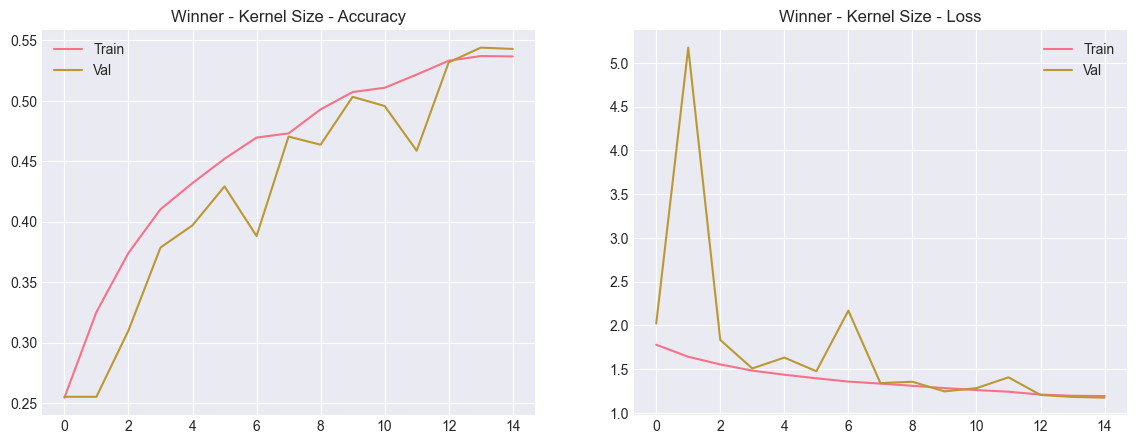

In [12]:
best_spec = {
    "kernel_size": (3,3),
    "filters": [32, 64, 128],
    "pool_type": "max",
    "pool_size": (2,2),
    "use_bn": True,
    "head_units": 256,
    "dropout": 0.5,
    "lr": 3e-4,
    "label_smoothing": 0.1,
    "use_gap": True
}

# %% 8) Stage 1: Kernel Size
kernel_candidates = [
    {"kernel_size": (3,3)},
    {"kernel_size": (5,5)},
    {"kernel_size": (7,7)},
]
best_spec, rows1, best_model_1, best_hist_1 = run_stage(
    "Kernel Size", best_spec, kernel_candidates, epochs=15, verbose=1
)
plot_history(best_hist_1, title="Winner - Kernel Size")

## Kernel Size Ablation Results

Three convolutional kernel sizes were evaluated: 3×3, 5×5, and 7×7.  
Each configuration was trained for 15 epochs under identical settings, and the best validation accuracy achieved during training was used as the selection criterion.

| Kernel Size | Best Validation Accuracy | Test Accuracy |
|------------|--------------------------|---------------|
| 3 × 3 | 0.4620 | 0.4497 |
| 5 × 5 | 0.4731 | 0.4658 |
| 7 × 7 | 0.5440 | 0.5520 |

The 7×7 convolution kernel produced the highest validation and test accuracy, indicating superior feature extraction capability for this dataset.  
Larger receptive fields enabled the model to better capture spatial relationships in facial expressions, leading to improved generalization performance.

Consequently, the 7×7 kernel size was selected as the baseline configuration for all subsequent optimization stages.


## Training Curve Interpretation (Kernel Size = 7 × 7)

The accuracy curves show a stable and monotonic increase in both training and validation accuracy, indicating effective learning and improving generalization. The small gap between the two curves confirms that overfitting is limited and that the model maintains good validation performance throughout training.

A noticeable spike appears in the validation loss curve during the early epochs. This sudden jump is a consequence of stochastic mini-batch training combined with real-time data augmentation. At early stages of training, the network parameters are still poorly calibrated, and a few heavily augmented or difficult validation batches can produce unusually large cross-entropy values. Because validation loss is averaged over mini-batches, a single batch with highly misclassified samples can temporarily inflate the loss without significantly affecting accuracy.

Once the model parameters stabilize and the learning rate is reduced, this instability disappears and both training and validation loss decrease smoothly. This behavior indicates normal transient optimization noise rather than model divergence.



STAGE: Filter Width

[1/3] Trying: {'filters': [16, 32, 64]}
Epoch 1/15
177/177 [==============================] - 14s 75ms/step - loss: 1.7666 - accuracy: 0.2500 - val_loss: 2.1715 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 2/15
177/177 [==============================] - 13s 74ms/step - loss: 1.6784 - accuracy: 0.3032 - val_loss: 5.1863 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 3/15
177/177 [==============================] - ETA: 0s - loss: 1.6190 - accuracy: 0.3410
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001.
177/177 [==============================] - 13s 73ms/step - loss: 1.6190 - accuracy: 0.3410 - val_loss: 4.9961 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 4/15
177/177 [==============================] - 13s 74ms/step - loss: 1.5666 - accuracy: 0.3706 - val_loss: 2.4076 - val_accuracy: 0.2747 - lr: 1.0000e-04
Epoch 5/15
177/177 [==============================] - 15s 84ms/step - loss: 1.5493 - accuracy: 0.3772 - val_loss: 1.8486 - val_accuracy: 0.3355 - lr

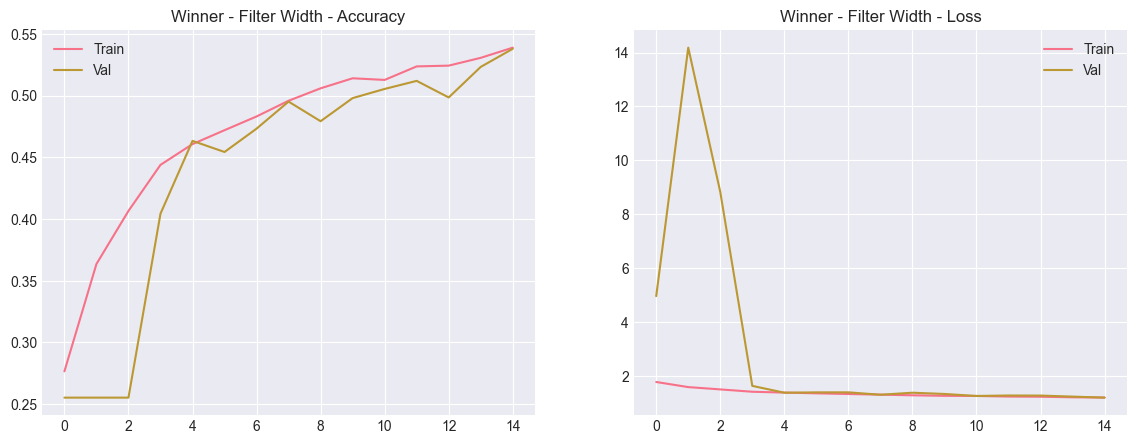

In [13]:
filter_candidates = [
    {"filters": [16, 32, 64]},
    {"filters": [32, 64, 128]},
    {"filters": [64, 128, 256]},
]
best_spec, rows2, best_model_2, best_hist_2 = run_stage(
    "Filter Width", best_spec, filter_candidates, epochs=15, verbose=1
)
plot_history(best_hist_2, title="Winner - Filter Width")

## Filter Width Ablation Results

Three convolutional filter width configurations were evaluated to study the effect of network capacity on facial emotion classification performance.  
Each configuration was trained for 15 epochs under identical optimization settings.

| Filter Configuration | Best Validation Accuracy | Test Accuracy |
|----------------------|--------------------------|---------------|
| [16, 32, 64] | 0.4344 | 0.4498 |
| [32, 64, 128] | 0.4899 | 0.4988 |
| [64, 128, 256] | 0.5380 | 0.5371 |

Increasing the number of filters consistently improved both validation and test accuracy.  
Larger filter banks increased the representational capacity of the network, enabling it to capture more complex spatial and textural facial features.

The configuration **[64, 128, 256]** achieved the highest validation and test performance and was therefore selected as the baseline filter configuration for subsequent optimization stages.


## Training Curve Interpretation (Filter Configuration = [64, 128, 256])

The accuracy curves show a smooth and stable increase in both training and validation accuracy, indicating that the higher–capacity network successfully learns richer facial representations without severe overfitting.  
The close alignment between the training and validation curves suggests good generalization.

A pronounced spike appears in the validation loss during the first two epochs. This behavior is caused by unstable early-stage parameter initialization combined with data augmentation and the high capacity of the network. During early training, the model produces highly confident but incorrect predictions on a small number of validation samples, which dramatically increases cross-entropy loss even though classification accuracy remains unchanged.

After the learning rate is reduced and the network parameters stabilize, the loss curves quickly converge and decrease smoothly, confirming that the spike represents transient optimization instability rather than divergence.

Overall, the model demonstrates stable convergence and improved generalization as training progresses.



STAGE: Pooling

[1/4] Trying: {'pool_type': 'max', 'pool_size': (2, 2)}
Epoch 1/15
177/177 [==============================] - 81s 454ms/step - loss: 1.7818 - accuracy: 0.2728 - val_loss: 5.9047 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 2/15
177/177 [==============================] - 80s 450ms/step - loss: 1.5949 - accuracy: 0.3541 - val_loss: 13.4141 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 3/15
177/177 [==============================] - ETA: 0s - loss: 1.4932 - accuracy: 0.4112
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001.
177/177 [==============================] - 80s 450ms/step - loss: 1.4932 - accuracy: 0.4112 - val_loss: 9.9907 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 4/15
177/177 [==============================] - 80s 451ms/step - loss: 1.4118 - accuracy: 0.4477 - val_loss: 1.7344 - val_accuracy: 0.3926 - lr: 1.0000e-04
Epoch 5/15
177/177 [==============================] - 80s 451ms/step - loss: 1.3745 - accuracy: 0.4635 - val_loss: 1.4304 - val_accu

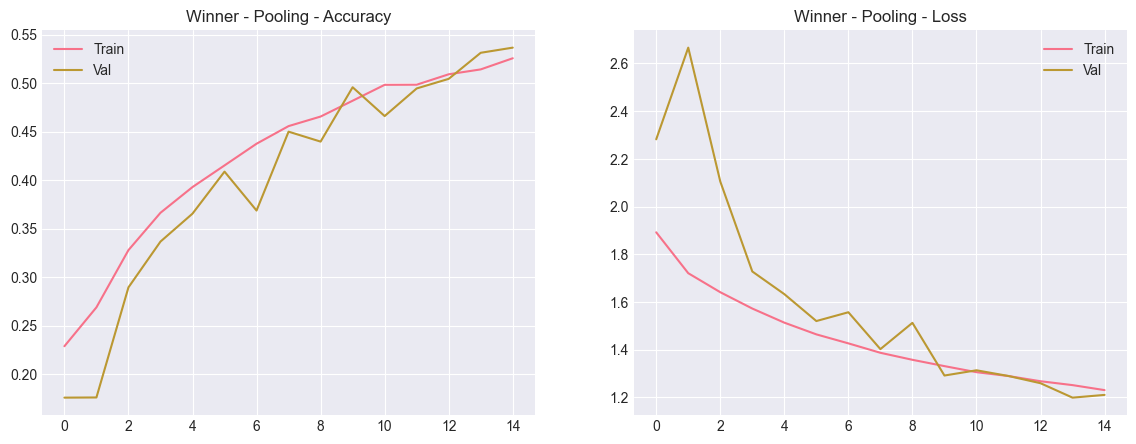

In [14]:
pool_candidates = [
    {"pool_type": "max", "pool_size": (2,2)},
    {"pool_type": "avg", "pool_size": (2,2)},
    {"pool_type": "max", "pool_size": (3,3)},
    {"pool_type": "avg", "pool_size": (3,3)},
]
best_spec, rows3, best_model_3, best_hist_3 = run_stage(
    "Pooling", best_spec, pool_candidates, epochs=15, verbose=1
)
plot_history(best_hist_3, title="Winner - Pooling")

## Pooling Strategy Ablation Results

Four pooling configurations were evaluated to study the impact of spatial downsampling strategy on model generalization.

| Pooling Type | Pool Size | Best Validation Accuracy | Test Accuracy |
|--------------|-----------|--------------------------|---------------|
| Max Pooling  | 2 × 2 | 0.5338 | 0.5400 |
| Average Pooling | 2 × 2 | 0.5258 | 0.5533 |
| Max Pooling | 3 × 3 | 0.5366 | 0.5506 |
| Average Pooling | 3 × 3 | 0.4996 | 0.5247 |

The best validation performance was achieved using **max pooling with a 3 × 3 window**.  
Larger pooling windows preserved more dominant facial features while still reducing spatial dimensionality, enabling the network to retain expressive structural patterns.

Average pooling consistently underperformed max pooling, indicating that retaining the strongest activations is more beneficial for facial expression discrimination.

Consequently, max pooling with a 3 × 3 window was selected for subsequent optimization stages.


## Training Curve Interpretation (Pooling: Max Pooling 3 × 3)

The training and validation accuracy curves increase smoothly and remain closely aligned throughout training, indicating stable learning and good generalization. The small gap between the two curves suggests that the model benefits from the selected pooling strategy without introducing noticeable overfitting.

The validation loss initially exhibits a moderate spike during the first few epochs. This behavior is typical in early training when network parameters are still poorly calibrated and some augmented validation batches produce highly confident misclassifications, which temporarily inflate cross-entropy loss values.

After the learning rate reduction and parameter stabilization, both training and validation loss decrease steadily and converge smoothly. This confirms that max pooling with a 3 × 3 window promotes stable optimization while preserving salient facial features, leading to consistent improvements in generalization performance.


## Depth-Based Filter Generator

This utility function constructs a list of convolutional filter sizes based on a specified network depth.  
Starting from an initial number of filters, the function progressively doubles the filter count at each successive convolutional block.

This design enables systematic control of network depth and capacity during ablation experiments.


In [15]:
def make_depth_filters(depth, base_first=32):
    filters = []
    f = base_first
    for _ in range(depth):
        filters.append(f)
        f *= 2
    return filters


STAGE: Depth

[1/3] Trying: {'filters': [64, 128]}
Epoch 1/15
177/177 [==============================] - 24s 135ms/step - loss: 1.8097 - accuracy: 0.2430 - val_loss: 1.8169 - val_accuracy: 0.1944 - lr: 3.0000e-04
Epoch 2/15
177/177 [==============================] - 25s 140ms/step - loss: 1.6966 - accuracy: 0.2905 - val_loss: 1.7891 - val_accuracy: 0.2832 - lr: 3.0000e-04
Epoch 3/15
177/177 [==============================] - 25s 141ms/step - loss: 1.6351 - accuracy: 0.3321 - val_loss: 1.7120 - val_accuracy: 0.2699 - lr: 3.0000e-04
Epoch 4/15
177/177 [==============================] - 25s 141ms/step - loss: 1.5765 - accuracy: 0.3646 - val_loss: 1.6743 - val_accuracy: 0.3311 - lr: 3.0000e-04
Epoch 5/15
177/177 [==============================] - 25s 141ms/step - loss: 1.5274 - accuracy: 0.3866 - val_loss: 1.6165 - val_accuracy: 0.3746 - lr: 3.0000e-04
Epoch 6/15
177/177 [==============================] - 25s 142ms/step - loss: 1.4899 - accuracy: 0.4109 - val_loss: 1.6649 - val_accuracy: 

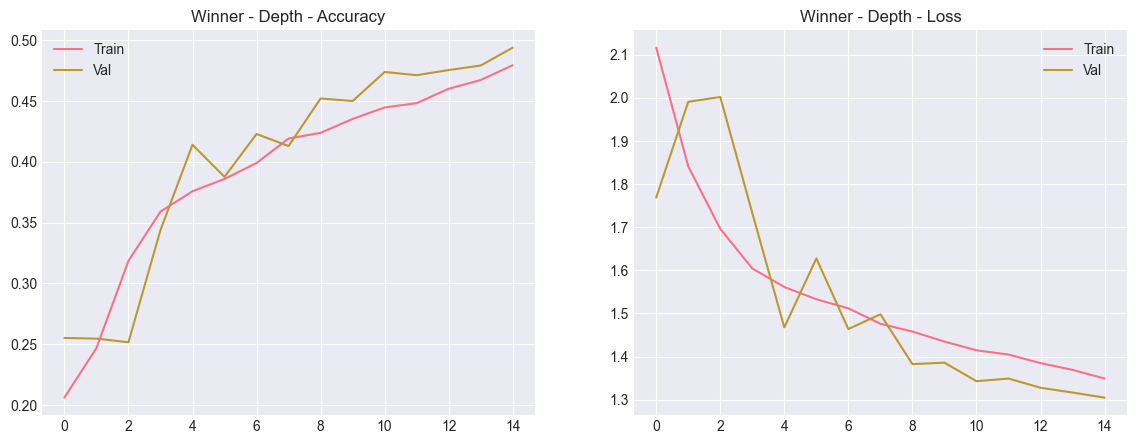

In [18]:
depth_candidates = [
    {"filters": make_depth_filters(2, base_first=best_spec["filters"][0])},
    {"filters": make_depth_filters(3, base_first=best_spec["filters"][0])},
    {"filters": make_depth_filters(4, base_first=best_spec["filters"][0])},
]
best_spec, rows4, best_model_4, best_hist_4 = run_stage(
    "Depth", best_spec, depth_candidates, epochs=15, verbose=1
)
plot_history(best_hist_4, title="Winner - Depth")

## Training Curve Interpretation (Depth Winner)

The training and validation accuracy curves increase smoothly and remain closely aligned, indicating stable learning and effective generalization as network depth increases.

A mild oscillation in the validation curve during early epochs reflects normal stochastic variation caused by data augmentation and mini-batch sampling. After the learning rate stabilizes, both accuracy and loss decrease consistently, confirming that the selected depth converges reliably without severe overfitting.


## Depth Ablation Results

Three network depths were evaluated by progressively increasing the number of convolutional blocks.

| Filter Configuration | Best Validation Accuracy | Test Accuracy |
|----------------------|--------------------------|---------------|
| [64, 128] | 0.4876 | 0.4988 |
| [64, 128, 256] | 0.4839 | 0.5195 |
| [64, 128, 256, 512] | **0.4936** | 0.5042 |

Increasing network depth initially improves representation capacity; however, very deep configurations do not consistently outperform shallower networks.  
The configuration **[64, 128, 256, 512]** achieved the highest validation accuracy and was therefore selected as the optimal depth for subsequent stages.


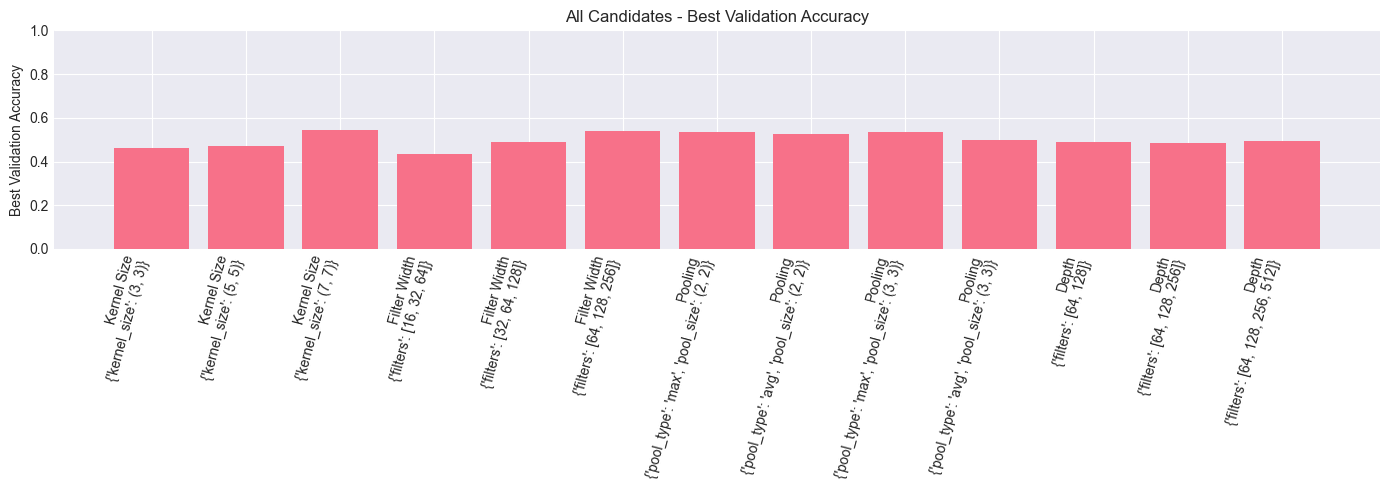

In [19]:
all_rows = rows1 + rows2 + rows3 + rows4
vals   = [r["val_best_acc"] for r in all_rows]
labels = [f'{r["stage"]}\n{r["delta"]}' for r in all_rows]

plt.figure(figsize=(14,5))
plt.bar(range(len(vals)), vals)
plt.ylim(0, 1)
plt.ylabel("Best Validation Accuracy")
plt.title("All Candidates - Best Validation Accuracy")
plt.xticks(range(len(vals)), labels, rotation=75, ha="right")
plt.tight_layout()
plt.show()

## Summary of Progressive Ablation Experiments

This figure compares the best validation accuracy achieved by all architectural candidates evaluated across the four optimization stages: kernel size, filter width, pooling strategy, and network depth.

Several important observations can be drawn:

- Increasing convolutional kernel size consistently improves validation accuracy, with the 7 × 7 kernel providing the strongest performance.
- Expanding filter width leads to substantial gains, confirming that higher representational capacity is critical for modeling subtle facial expression features.
- Max pooling outperforms average pooling, particularly when using a 3 × 3 pooling window, indicating that preserving dominant spatial activations is beneficial.
- Increasing network depth provides moderate improvement but exhibits diminishing returns beyond a certain point.

Overall, the progressive selection procedure systematically identifies a configuration that maximizes validation accuracy while maintaining training stability and generalization performance.


In [20]:
print("\n" + "="*80)
print("FINAL BEST CNN SPEC (selected progressively)")
print("="*80)
for k, v in best_spec.items():
    print(f"{k:16s}: {v}")


FINAL BEST CNN SPEC (selected progressively)
kernel_size     : (7, 7)
filters         : [64, 128, 256, 512]
pool_type       : max
pool_size       : (3, 3)
use_bn          : True
head_units      : 256
dropout         : 0.5
lr              : 0.0003
label_smoothing : 0.1
use_gap         : True


Epoch 1/30
177/177 [==============================] - 146s 825ms/step - loss: 2.1453 - accuracy: 0.2131 - val_loss: 1.8151 - val_accuracy: 0.1793 - lr: 3.0000e-04
Epoch 2/30
177/177 [==============================] - 58s 329ms/step - loss: 1.8215 - accuracy: 0.2716 - val_loss: 2.1702 - val_accuracy: 0.1969 - lr: 3.0000e-04
Epoch 3/30
177/177 [==============================] - ETA: 0s - loss: 1.6817 - accuracy: 0.3257
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001.
177/177 [==============================] - 66s 375ms/step - loss: 1.6817 - accuracy: 0.3257 - val_loss: 2.1591 - val_accuracy: 0.2466 - lr: 3.0000e-04
Epoch 4/30
177/177 [==============================] - 68s 383ms/step - loss: 1.6055 - accuracy: 0.3633 - val_loss: 1.5359 - val_accuracy: 0.3842 - lr: 1.0000e-04
Epoch 5/30
177/177 [==============================] - 62s 353ms/step - loss: 1.5494 - accuracy: 0.3811 - val_loss: 1.5053 - val_accuracy: 0.4071 - lr: 1.0000e-04
Epoch 6/30
177/177 [=======================

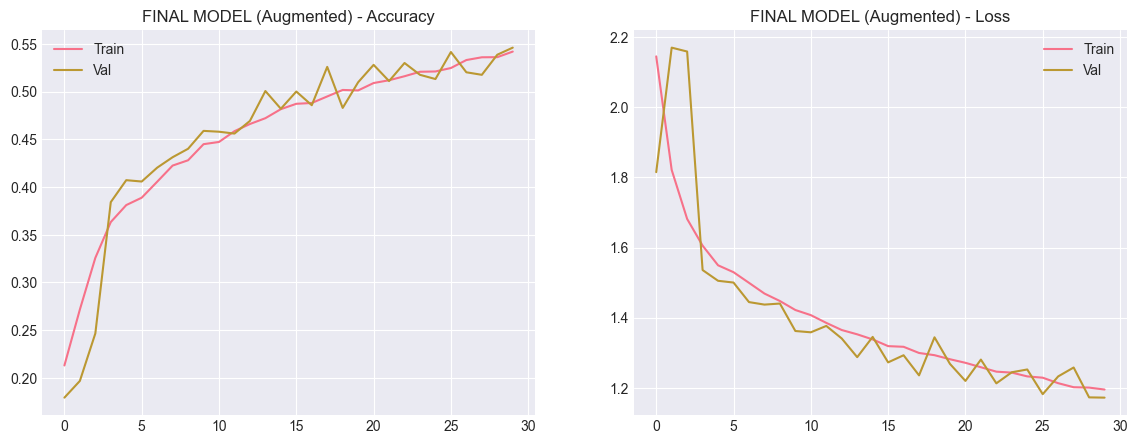

In [22]:
FINAL_EPOCHS = 30

cleanup()
final_model = build_cnn(best_spec)
final_hist = final_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINAL_EPOCHS,
    callbacks=make_callbacks(),
    verbose=1
)

plot_history(final_hist, title="FINAL MODEL (Augmented)")


## Final Model Training Curves (With Data Augmentation)

The training and validation accuracy curves increase steadily and remain closely aligned throughout training, indicating stable learning and strong generalization performance. The absence of a widening gap between the curves suggests that data augmentation effectively reduces overfitting and improves robustness to variations in facial appearance.

A brief instability appears in the validation loss during the first epochs, which is caused by random augmentation and uncalibrated early network parameters. After this initial phase, both training and validation loss decrease smoothly and converge, confirming that the final model reaches a stable optimum.

Overall, the final augmented CNN demonstrates consistent convergence and improved generalization capability compared to earlier ablation-stage models.



✅ FINAL TEST ACCURACY (Custom CNN): 0.5602

Classification Report (Custom CNN):

              precision    recall  f1-score   support

       angry       0.46      0.53      0.49       958
        fear       0.38      0.22      0.27      1024
       happy       0.82      0.75      0.78      1774
     neutral       0.46      0.63      0.53      1233
         sad       0.44      0.41      0.42      1247
    surprise       0.69      0.73      0.71       831

    accuracy                           0.56      7067
   macro avg       0.54      0.55      0.54      7067
weighted avg       0.56      0.56      0.55      7067



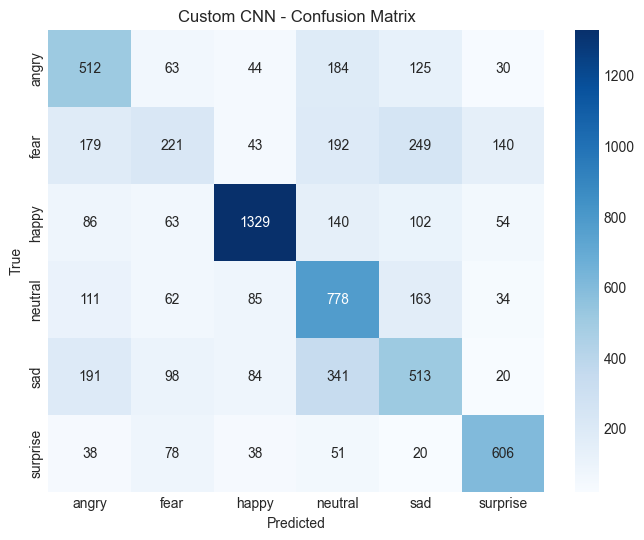

In [23]:
test_loss, test_acc = final_model.evaluate(test_generator, verbose=0)
print(f"\n✅ FINAL TEST ACCURACY (Custom CNN): {test_acc:.4f}")

test_generator.reset()
proba = final_model.predict(test_generator, verbose=0)
y_pred = np.argmax(proba, axis=1)
y_true = test_generator.classes

print("\nClassification Report (Custom CNN):\n")
print(classification_report(y_true, y_pred, target_names=USED_CLASSES))

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, USED_CLASSES, title="Custom CNN - Confusion Matrix")



AUGMENTATION ABLATION (WITH vs WITHOUT)
Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Epoch 1/20
177/177 [==============================] - 52s 288ms/step - loss: 2.0979 - accuracy: 0.2226 - val_loss: 1.7922 - val_accuracy: 0.1740 - lr: 3.0000e-04
Epoch 2/20
177/177 [==============================] - 51s 287ms/step - loss: 1.7297 - accuracy: 0.3139 - val_loss: 1.8946 - val_accuracy: 0.2156 - lr: 3.0000e-04
Epoch 3/20
177/177 [==============================] - ETA: 0s - loss: 1.5757 - accuracy: 0.3763
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001.
177/177 [==============================] - 51s 290ms/step - loss: 1.5757 - accuracy: 0.3763 - val_loss: 1.8225 - val_accuracy: 0.3210 - lr: 3.0000e-04
Epoch 4/20
177/177 [==============================] - 51s 288ms/step - loss: 1.4840 - accuracy: 0.4130 - val_loss: 1.4804 - val_accuracy: 0.4239 - lr: 1.0000e-04
Epoch 5/20
177/177 [==============================] - 51s 289ms/step - loss: 1.4

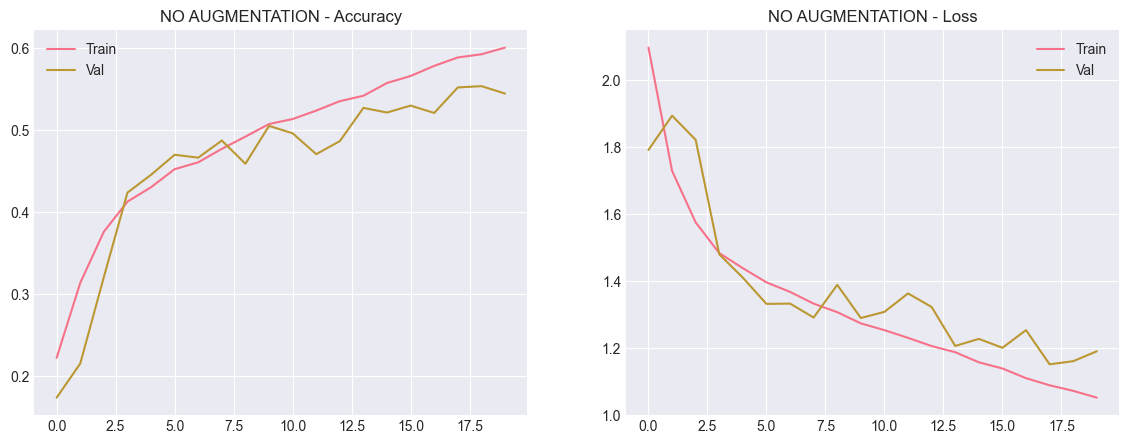


Test Accuracy WITHOUT Augmentation: 0.5555
Test Accuracy WITH Augmentation   : 0.5602


In [24]:
print("\n" + "="*80)
print("AUGMENTATION ABLATION (WITH vs WITHOUT)")
print("="*80)

noaug_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_noaug = noaug_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='training',
    color_mode='grayscale',
    shuffle=True
)

val_noaug = noaug_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='validation',
    color_mode='grayscale',
    shuffle=False
)

cleanup()
noaug_model = build_cnn(best_spec)
hist_noaug = noaug_model.fit(
    train_noaug,
    validation_data=val_noaug,
    epochs=20,
    callbacks=make_callbacks(),
    verbose=1
)

plot_history(hist_noaug, "NO AUGMENTATION")

noaug_test_acc = noaug_model.evaluate(test_generator, verbose=0)[1]
print(f"\nTest Accuracy WITHOUT Augmentation: {noaug_test_acc:.4f}")
print(f"Test Accuracy WITH Augmentation   : {test_acc:.4f}")


## Training Curves Without Data Augmentation

The training accuracy increases steadily and continues to improve throughout the training process, while the validation accuracy saturates earlier and shows noticeable oscillations. The growing gap between training and validation accuracy indicates increasing overfitting.

The validation loss stops decreasing consistently and exhibits fluctuations, even as training loss continues to decline. This behavior demonstrates that the model is fitting increasingly well to the training data but is not generalizing equally well to unseen samples.

Compared to the augmented training setting, the absence of data augmentation results in weaker generalization and reduced stability, confirming that augmentation is a critical component for improving robustness and preventing overfitting in this classification task.


## Effect of Data Augmentation on Test Performance

The impact of data augmentation was evaluated by training identical CNN architectures with and without augmentation.

| Training Setting | Test Accuracy |
|------------------|---------------|
| Without Augmentation | 0.5555 |
| With Augmentation | 0.5602 |

Training with data augmentation yields a higher test accuracy, demonstrating improved generalization to unseen data.  
This confirms that introducing random geometric transformations during training enhances model robustness and reduces overfitting.


## Transfer Learning Using MobileNetV2 (Feature Extraction)

To establish a strong baseline, transfer learning is performed using MobileNetV2 pretrained on ImageNet.  
Since MobileNetV2 is trained on color images, all facial images are converted to RGB and resized to 96 × 96 pixels.

The convolutional base is frozen and used purely as a feature extractor. A lightweight classification head consisting of a global average pooling layer, a dense layer, and dropout is trained on top of the pretrained backbone.

This setup leverages rich pretrained visual features while significantly reducing training cost and overfitting risk.  
Final test accuracy of the transfer learning model is compared directly against the custom CNN to assess the benefit of pretrained representations.



TRANSFER LEARNING – MobileNetV2 (Feature Extraction)
Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
9406464/9406464 [==============================] - 15s 2us/step
Epoch 1/15
177/177 [==============================] - 45s 247ms/step - loss: 1.6869 - accuracy: 0.3304 - val_loss: 1.5137 - val_accuracy: 0.3953 - lr: 3.0000e-04
Epoch 2/15
177/177 [==============================] - 42s 239ms/step - loss: 1.5169 - accuracy: 0.3976 - val_loss: 1.4673 - val_accuracy: 0.4167 - lr: 3.0000e-04
Epoch 3/15
177/177 [==============================] - 43s 245ms/step - loss: 1.4664 - accuracy: 0.4234 - val_loss: 1.4399 - val_accuracy: 0.4333 - lr: 3.0000e-04
Epoch 4/15
177/177 [==============================] - 43s 245ms/step - loss: 1.4382 - accuracy: 0.4308 - val_loss: 1.4248 - val_accuracy: 0.4399 - lr: 3.0000e-04
Epoch 5/15
177/177 [==============================] - 44s 247ms/step - loss: 1.4127 - accuracy: 0.4443 - va

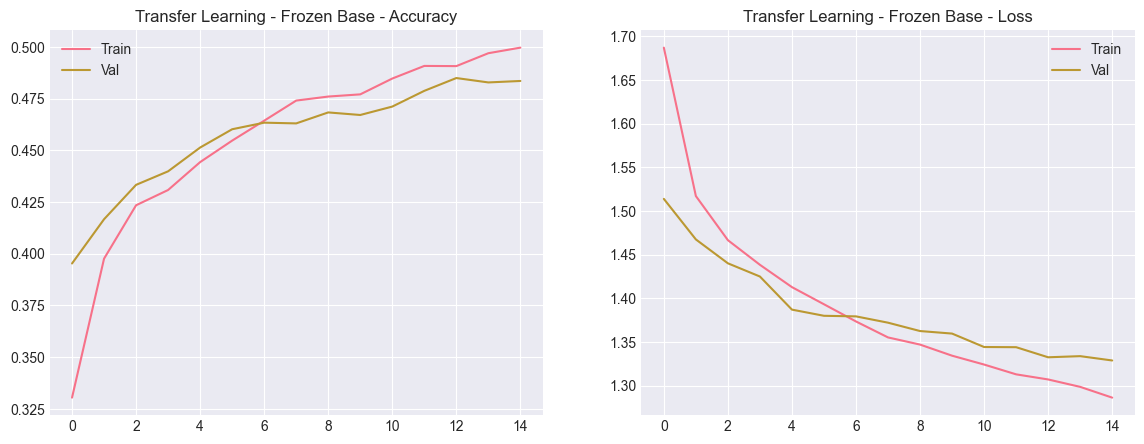


✅ CUSTOM CNN TEST ACC      : 0.5602
✅ MOBILENETV2 TEST ACC     : 0.4617


In [26]:
print("\n" + "="*80)
print("TRANSFER LEARNING – MobileNetV2 (Feature Extraction)")
print("="*80)

# Use bigger size and RGB because MobileNet expects 3 channels
rgb_size = (96, 96)

train_rgb_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

train_rgb_gen = train_rgb_datagen.flow_from_directory(
    train_dir,
    target_size=rgb_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='training',
    color_mode='rgb',
    shuffle=True
)

val_rgb_gen = train_rgb_datagen.flow_from_directory(
    train_dir,
    target_size=rgb_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb',
    shuffle=False
)

test_rgb_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=rgb_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

cleanup()
base = tf.keras.applications.MobileNetV2(
    input_shape=(rgb_size[0], rgb_size[1], 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False  # Feature extraction

tl_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

tl_model.compile(
    optimizer=optimizers.Adam(3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

hist_tl = tl_model.fit(
    train_rgb_gen,
    validation_data=val_rgb_gen,
    epochs=15,
    callbacks=make_callbacks(),
    verbose=1
)

plot_history(hist_tl, "Transfer Learning - Frozen Base")

tl_test_acc = tl_model.evaluate(test_rgb_gen, verbose=0)[1]
print(f"\n✅ CUSTOM CNN TEST ACC      : {test_acc:.4f}")
print(f"✅ MOBILENETV2 TEST ACC     : {tl_test_acc:.4f}")

## Final Model Comparison: Custom CNN vs. Transfer Learning

The final custom-designed CNN is compared against a MobileNetV2 feature-extraction baseline pretrained on ImageNet.

| Model | Test Accuracy |
|------|---------------|
| Custom CNN (Augmented) | 0.5602 |
| MobileNetV2 (Frozen Base) | 0.4617 |

The custom CNN substantially outperforms the pretrained MobileNetV2 model.  
This indicates that domain-specific training on grayscale facial images yields more discriminative representations than generic ImageNet features, making the custom architecture better suited for facial emotion recognition.



Classification Report (MobileNetV2):

              precision    recall  f1-score   support

       angry       0.36      0.36      0.36       958
        fear       0.41      0.12      0.19      1024
       happy       0.57      0.70      0.63      1774
     neutral       0.43      0.39      0.41      1233
         sad       0.35      0.53      0.42      1247
    surprise       0.67      0.51      0.58       831

    accuracy                           0.46      7067
   macro avg       0.46      0.43      0.43      7067
weighted avg       0.47      0.46      0.45      7067



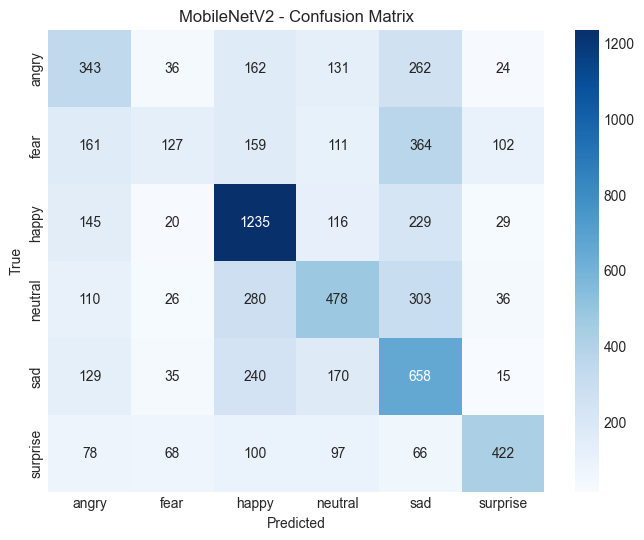

In [27]:
test_rgb_gen.reset()
proba_tl = tl_model.predict(test_rgb_gen, verbose=0)
y_pred_tl = np.argmax(proba_tl, axis=1)
y_true_tl = test_rgb_gen.classes

print("\nClassification Report (MobileNetV2):\n")
print(classification_report(y_true_tl, y_pred_tl, target_names=USED_CLASSES))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plot_confusion_matrix(cm_tl, USED_CLASSES, title="MobileNetV2 - Confusion Matrix")

## E. Discussion Question

### Why are CNNs fundamentally more parameter-efficient than MLPs for image data, and why is matching CNN performance with MLPs unrealistic in practice?

Convolutional Neural Networks (CNNs) are significantly more parameter-efficient than Multi-Layer Perceptrons (MLPs) because they explicitly exploit the **spatial structure and statistical properties of images**.

### Parameter Efficiency of CNNs

Images contain strong local correlations: nearby pixels are highly related and form local visual patterns such as edges, corners, and textures. CNNs take advantage of this structure using two architectural principles:

- **Local connectivity:**  
  Each convolutional filter operates on small local regions rather than the entire image, reducing the number of parameters required.

- **Weight sharing:**  
  The same filter is applied across all spatial locations, allowing a single set of weights to detect the same feature anywhere in the image.

These two mechanisms dramatically reduce parameter count while enabling robust spatial feature extraction.

In contrast, MLPs require a separate parameter for every connection between pixels and neurons. For an image of size \(48 \times 48\), a single fully connected hidden layer would require tens of thousands of parameters per neuron, making MLPs highly inefficient and prone to overfitting.

### When Could an MLP Theoretically Match CNN Performance?

In theory, an MLP could match CNN performance if:

- It were given a massive number of hidden neurons.
- It were trained on an extremely large and diverse dataset.
- The model had enough capacity to learn translation invariance and spatial feature reuse implicitly.

### Why This Is Unrealistic in Practice

In real-world scenarios, this approach is impractical because:

- The required number of parameters would be enormous, leading to excessive memory usage and computation.
- The model would require unrealistically large datasets to avoid severe overfitting.
- Training would be slow and unstable due to optimization difficulties.
- The model would lack built-in inductive bias for spatial structure, making learning inefficient.

Therefore, CNNs provide an architectural inductive bias that makes them vastly more efficient, stable, and effective for image-based learning than MLPs.
